# Семинар 3. Обзор А/Б-тест фреймворков. tea-tasting, HypEx, Growthbook.

In [ ]:
!pip install hypex==1.0.2

In [ ]:
import random
import pandas as pd
import numpy as np

pd.set_option('future.no_silent_downcasting', True)

In [ ]:
!python --version

Python 3.12.12


# [HypEx](https://github.com/sb-ai-lab/HypEx/)


In [ ]:
import hypex
hypex.__version__

'1.0.2'

## Генерация данных

- с двумя метриками (pre_spends,	post_spends)
- treat - метка группы
- есть фичи

In [ ]:
from hypex.utils.tutorial_data_creation import create_test_data

df = create_test_data()
df.head()

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry
0,0.0,0.0,0.0,492.5,415.222222,66.0,F,Logistics
1,1.0,1.0,1.0,535.5,520.666667,44.0,M,Logistics
2,2.0,0.0,0.0,500.0,421.666667,55.0,F,E-commerce
3,3.0,11.0,1.0,486.5,434.000000,49.0,F,E-commerce
4,4.0,0.0,0.0,493.0,431.000000,20.0,F,Logistics


In [ ]:
from hypex.dataset import Dataset, TargetRole, TreatmentRole, FeatureRole

# dataset with roles
data = Dataset(
    roles={
        'post_spends': TargetRole(),
        'treat': TreatmentRole(),
        'age': FeatureRole(),
        'gender': FeatureRole()
    },
    data=df
)

# Функциональность А/А-теста в Hypex

https://github.com/sb-ai-lab/HypEx/blob/11798490ee888b70292767f1929b80931c61f0a8/examples/tutorials/AATestTutorial.ipynb

- варианты стат. тестов
   - **t-test для разности средних** (scipy.stats.ttest_ind)
   - **непараметрический тест Колмогоров-Смирнов** (проверка что обе выборки из одного распределения)

- делится на группы через присвоение новых индексов shuffle

- большая инкапсуляция функциональности: стат.критерии зафиксированы и выдаются как результат

In [ ]:
from hypex import AATest

aa_test = AATest(
    n_iterations=100,
    stratification=True
)

results = aa_test.execute(data)

100%|██████████| 100/100 [00:07<00:00, 13.76it/s]


In [ ]:
# `aa-score` = Estimates mean passed score for t-test and ks-test in AA-test.
# `pass` = p_value < alpha
# score = доля итераций АА-теста, где тест показал не нашел разницу между группами
results.aa_score

,score,pass
post_spends TTest test,0.96,True
post_spends KSTest test,0.95,True


In [ ]:
results.experiments

,splitter_id,post_spends GroupDifference control mean test,post_spends GroupDifference test mean test,post_spends GroupDifference difference test,post_spends GroupDifference difference % test,post_spends TTest p-value test,post_spends TTest pass test,post_spends KSTest p-value test,post_spends KSTest pass test,mean TTest p-value,mean TTest pass,mean KSTest p-value,mean KSTest pass,mean test score
0,AASplitterWithStratification┴rs 0┴,451.016466,451.920395,0.903929,0.200420,0.277913,False,NaN,False,0.277913,0.0,0,0.0,0.092638
1,AASplitterWithStratification┴rs 1┴,451.960509,450.974921,-0.985588,-0.218070,0.236793,False,NaN,False,0.236793,0.0,0,0.0,0.078931
2,AASplitterWithStratification┴rs 2┴,451.693173,451.244845,-0.448329,-0.099255,0.590485,False,NaN,False,0.590485,0.0,0,0.0,0.196828
3,AASplitterWithStratification┴rs 3┴,451.637432,451.300773,-0.336659,-0.074542,0.686144,False,NaN,False,0.686144,0.0,0,0.0,0.228715
4,AASplitterWithStratification┴rs 4┴,451.559307,451.377589,-0.181718,-0.040242,0.827343,False,NaN,False,0.827343,0.0,0,0.0,0.275781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AASplitterWithStratification┴rs 95┴,451.203551,451.734439,0.530888,0.117660,0.523975,False,NaN,False,0.523975,0.0,0,0.0,0.174658
96,AASplitterWithStratification┴rs 96┴,451.326337,451.612435,0.286098,0.063391,0.731295,False,NaN,False,0.731295,0.0,0,0.0,0.243765
97,AASplitterWithStratification┴rs 97┴,451.522205,451.415951,-0.106254,-0.023532,0.898515,False,NaN,False,0.898515,0.0,0,0.0,0.299505
98,AASplitterWithStratification┴rs 98┴,450.845572,452.090797,1.245225,0.276198,0.134984,False,NaN,False,0.134984,0.0,0,0.0,0.044995


# Функционал А/В теста Hypex

## Критерии

- t-test
- Манна-Уитни (U-test)

In [ ]:
from hypex import ABTest

ab_test = ABTest(additional_tests=['t-test', 'u-test'])
result = ab_test.execute(data)
result.resume

,feature,group,control mean,test mean,difference,difference %,TTest pass,TTest p-value,UTest pass,UTest p-value
0,post_spends,1.0,419.720582,483.751114,64.030532,15.255514,OK,0.0,OK,0.0


In [ ]:
result.sizes

,control size,test size,control size %,test size %,group
1.0,4538,4463,50.41662,49.58338,1.0


# Более 2 групп - поправки

In [ ]:
# бъем на 3 группы
df_h = df.copy()
df_h["treat"] = [random.choice([0, 1, 2]) for _ in range(len(df_h))]
df_h['treat'].value_counts()

,count
treat,
0,3374
1,3329
2,3297


In [ ]:
# переопределяем датасет
data_h = Dataset(
    roles={
        'post_spends': TargetRole(),
        'treat': TreatmentRole(),
        'age': FeatureRole(),
        'gender': FeatureRole()
    },
    data=df_h
)

`group`: treat = 0 – контроль, 1 и 2 – две тестовые:
- строка с group = 1 гипотеза «группа 1 отличается от контроля»
- строка с group = 2 гипотеза «группа 2 отличается от контроля»

`rejected`- итог по каждой гипотезе с учётом коррекции:
- True → нулевая гипотеза «нет эффекта» отвергнута;
- False → нулевая гипотеза не отвергнута.

In [ ]:
# Для Бонферрони: p_adj = min(p * m, 1), где m – число гипотез
multitest = ABTest(multitest_method="bonferroni")
result = multitest.execute(data_h)
result.multitest


,field,test,old p-value,new p-value,correction,rejected,group
0,post_spends,TTest,0.070863,0.141726,0.5,False,1
1,post_spends,TTest,0.125947,0.251893,0.5,False,2


# Мэтчинг

### Почему отсутствует А/B :

- аналитиков забыли спросить (а менеджер хочет премию перед нг и скорее выкатил фичу на всех)
- вы решили измерить эффект того, что работало ДО вас
- А/B тест невозможно провести по логической причине (не можем кому-то дать кредит, а кому-то - не дать без причины, или это медицинское исследование с серьезными последствиями для здоровья)



Сценарий:
Вы хотите понять, приводит ли «самостоятельное открытие» пользователем определённой функциональности сервиса (например, использование функции «Пропустить заставку») к изменению его дальнейшего паттерна потребления, например, spend (времени в приложении).

**Почему нельзя провести классический A/B-тест:**

Данный функционал уже доступен всем пользователям. Некоторые из них сами «наткнулись» на эту функцию и стали активно ею пользоваться, а другие - нет.
Невозможно рандомизировать и заставить одну группу пользователей «случайным образом» начать пользоваться функцией, а другую - нет. То есть вы не можете назначить условие эксперимента так, как это делается с новыми фичами, которые показываются одной группе и не показываются другой.
Пользователи сами принимают решение осваивать или не осваивать определённый функционал, и вы не можете искусственно контролировать это решение.

Итог:

вы не можете присвоить «treatment» (использование функции) и «control» (неиспользование) путём случайного распределения. Поведение пользователей - их собственный выбор. Это затрудняет применение классического A/B-теста и вынуждает обращаться к наблюдательным данным, методам causal анализа или к построению соответствия между пользователями, добровольно использующими функционал, и похожими на них пользователями, которые его не используют.

# Causal Inference основы

Когда ищем
- связь X -> Y (Х влияет на Y)
- величину влияния

Не корреляция, а именно влияние (causation [козЭйшн](https://youglish.com/pronounce/causation/english) ):


```Correlation does not imply causation.```

## Основные термины

- существуют юниты $i=1..N$ — клиенты, пациенты и тд;
- они находятся под определенным treatment’ом $t=[0,1]$ — переменная, имеющая 2 разных варианта;
- потенциальные исходы $Y(i)$ (potential outcomes) — результат или итог, верный под определенным условием (treatment’ом). Как правило, это наша целевая метрика, которую мы анализируем в А/В.
-  covariates $z_i$ — другие переменные (массив переменных), относящиеся к юниту i и влияющие на потенциальные исходы этого юнита. Например, в случае пользователя сайта, это может быть его возраст, дата регистрации или первой покупки.

## Хотим посчитать
$$Y(i|t=1) — Y(i|t=0)$$

 но это невозможно (для одного и того же юнита, только если в параллельных вселенных, так как не можем одновременно применить и не применить treatment) = фундаментальная проблема causal парадигмы

Поэтому мы **разделяем пользователей на 2 группы**, основываясь на предположении, что пользователиэтих групп похожи, treatment распределен независимо и тогда  вместо $Y(i|t=1) — Y(i|t=0)$ оцениваем метрики:

**ATE = Average treatment effect**
$$ATE = E[Y(i|t=1) — Y(i|t=0)]$$


**ATT = Average treatment effect on the treated**
= разница в таргетной группе между тем, какой потенциальный исход мы имеем (после применения маркетинговой акции или запуска новой фичи), и тем, каким он был бы в случае отсутствия treatment’а.

$$ATT = E[Y(i=1|t=1) — Y(i=0|t=1)] $$

```y_treated - y_match_treated```

**ATC Average Treatment Effect for the control group (ATC)**

$$ATC = E[Y(i=1|t=0) — Y(i=0|t=0)]$$

```y_match_untreated - y_untreated```

И тогда $$ATE = \frac{N_{treat}}{N} ATT + \frac{N_{control}}{N} ATC$$

# Реализация мэтчинга в Hypex

Механизм matching-метода:
- каждому юниту из тритмента подбирается идентичный из контрола и наоборот

Точного совпадения может не быть, но выбирается метрика “близости” и некий порог для нее. Юниты, расстояние между которыми меньше порога, считаются сматченными.

Поиск ближайших соседей реализован через библиотеку Faiss


- далее внутри **каждой** пары считается эффект (то есть разница в таргете)

- который затем усредняется для получения ATE, ATT и ATC.

Здесь ATT и ATC - вспомогательные метрики, на основе которых затем считается ATE как их взвешенная сумма.




## Гипотезы для проверки над данными

В ходе расчетов будем проверять гипотезу о том, что (например, для ATE)

$H_0: АTE=0$

Интерпретация: под нулевой гипотезой мы предполагаем, что наличие treatment не меняет среднюю целевую метрику по сравнению с ситуацией без treatment.

$H_1: ATE != 0$

Альтернативная гипотеза, что эффект от вмешательства treatment есть

- p_value считается с помощью одновыброчного [z-test](https://en.wikipedia.org/wiki/Z-test). Он применяется для проверки гипотезы о среднем значении генеральной совокупности - так как по ЦПТ предполагаем, что ATE и прочие метрики распределены нормально (это же матожидания)

In [ ]:
# hypex=1.0.2; 21.11.2025
# IndexError: list index out of range

from hypex import Matching

test = Matching()
result = test.execute(data)

IndexError: list index out of range

# Переходим к более старому API hypex, которое работает

In [ ]:
# !pip install hypex==0.1.10

In [ ]:
from hypex.utils.tutorial_data_creation import create_test_data

data = create_test_data()

In [ ]:
from hypex import Matcher

model = Matcher(input_data=data, outcome=['post_spends'],
                treatment='treat', info_col=['user_id'])

In [ ]:
results, quality_results, df_matched = model.estimate()

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
results

,effect_size,std_err,p-val,ci_lower,ci_upper,outcome
ATE,83.717322,1.471949,0.0,80.832302,86.602343,post_spends
ATC,104.028064,2.798859,0.0,98.542300,109.513829,post_spends
ATT,63.528080,0.621631,0.0,62.309683,64.746477,post_spends


## Переменная quality_results содержит анализ распределений фичей:

### PSI (Population Stability Index)
разница между treated и untreated распределениями

	•	PSI < 1  → OK
	•	1 ≤ PSI < 2 → Warning
	•	PSI ≥ 2 → NOK — распределения сильно различаются

Что получается в результате: после матчинга признаки распределены по-разному, особенно signup_month.


### SMD (Standardized Mean Differences)

Стандартизированная разность средних (SMD) между исходным и сматченным датафреймами
помогает проверить, достигнут ли баланс между группами.

- Меньше 0.1.
Для рандомизированного эксперимента SMD по всем ковариатам обычно должен находиться в этом диапазоне.
- 0.1 – 0.2.
Не обязательно идеально сбалансировано, но разница достаточно мала, чтобы это обычно не вызывает серьёзных опасений.
- Больше 0.2.
Значения выше этого порога считаются признаком серьёзного дисбаланса

### Repeats
Доля повторяющися индексов

In [ ]:
show_result(quality_results)

psi


,column_treated,anomaly_score_treated,check_result_treated,column_untreated,anomaly_score_untreated,check_result_untreated
0,age_treated,0.00,OK,age_untreated,0.05,OK
1,gender_M_treated,0.00,OK,gender_M_untreated,0.00,OK
2,industry_Logistics_treated,0.00,OK,industry_Logistics_untreated,0.00,OK
3,pre_spends_treated,0.54,NOK,pre_spends_untreated,0.19,OK
4,signup_month_treated,16.15,NOK,signup_month_untreated,0.00,OK



ks_test


,match_control_to_treat,match_treat_to_control
age,4.228608e-01,4.356483e-04
pre_spends,1.850193e-212,4.330001e-29
signup_month,0.000000e+00,0.000000e+00



smd


,match_control_to_treat,match_treat_to_control
age,0.017855,0.010480
pre_spends,0.564427,0.110849
signup_month,1.879261,inf



repeats


{'match_control_to_treat': 0.44, 'match_treat_to_control': 0.08}

In [ ]:
# визуально сравнить сопоставленные пары
df_matched.head(100)

,index,signup_month,pre_spends,age,gender_M,industry_Logistics,signup_month_matched,pre_spends_matched,age_matched,gender_M_matched,industry_Logistics_matched,index_matched,post_spends,post_spends_matched,post_spends_matched_bias,treat,treat_matched
0,7981,10,474.5,28,1,0,0.0,497.0,28.0,1.0,0.0,[2701],436.222222,433.000000,2.811041,1,0
1,1007,11,478.5,50,1,0,0.0,503.5,50.0,1.0,0.0,[3825],434.222222,414.777778,18.987577,1,0
2,7264,5,472.5,28,1,1,0.0,483.0,28.0,1.0,1.0,[1328],498.444444,412.111111,86.141449,1,0
3,7283,7,488.5,34,0,1,0.0,503.5,34.0,0.0,1.0,[3820],483.555556,401.777778,81.503657,1,0
4,7247,5,476.5,45,1,1,0.0,488.0,45.0,1.0,1.0,[8089],495.666667,416.444444,79.012063,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,8143,10,483.5,30,0,0,0.0,505.0,29.0,0.0,0.0,[6098],419.444444,419.000000,0.042955,1,0
96,7184,1,534.5,22,0,1,0.0,537.5,22.0,0.0,1.0,[1689],521.444444,419.888889,101.500731,1,0
97,928,9,494.0,32,0,1,0.0,514.0,31.0,0.0,1.0,[6587],452.555556,409.777778,42.403701,1,0
98,8114,9,495.0,59,0,0,0.0,514.0,59.0,0.0,0.0,[6750],450.333333,422.333333,27.652780,1,0


# `Growthbook` - open source платформа для выкатки A/B-тестов + SDK Python

https://github.com/growthbook

https://docs.growthbook.io/self-host


## Техническая реализация

- `Feature Flag` — это кусок кода, позволяющий управлять включением или отключением определённых функций или возможностей в приложении без необходимости изменения или развертывания нового кода. По сути, это условные переключатели, которые контролируют доступность тех или иных частей функционала для пользователей.

Их выносят в админку, чтобы можно было собрать конфигурацию А/Б теста


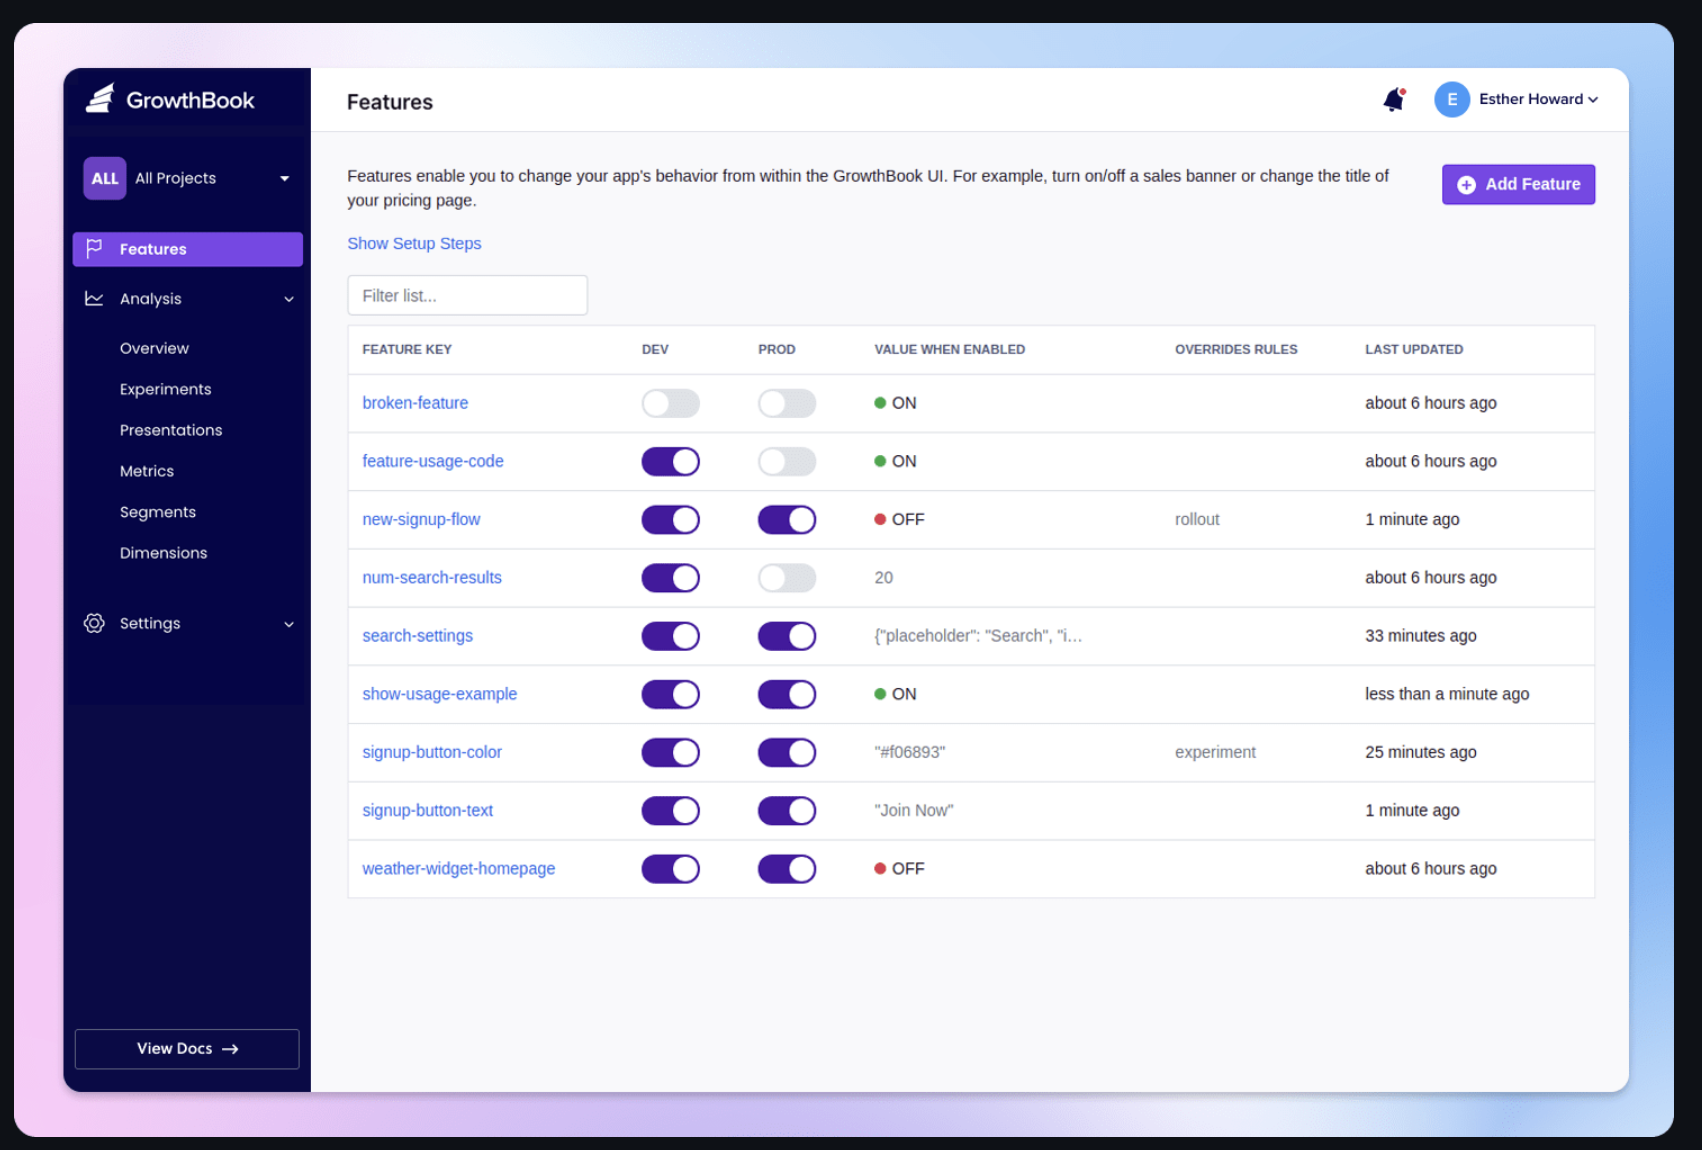

```
# пример feature flag

from feature_flags import FEATURE_FLAGS

def old_greeting():
    return "Добро пожаловать в наше приложение!"

def new_greeting():
    return "Здравствуйте! Мы рады видеть вас в нашем обновленном приложении."

def get_greeting():
    if FEATURE_FLAGS.get("new_greeting"):
        return new_greeting()
    else:
        return old_greeting()

if __name__ == "__main__":
    print(get_greeting())
```


## Математика  https://docs.growthbook.io/statistics/overview

- Bayesian Statistics

Instead of p-values and confidence intervals, you get probabilities and distributions of likely outcomes. These values allow you to make statements like "there’s a 95% chance this new button is better and a 5% chance it’s worse"

- Frequentist (классические А/B-тесты)
  - The current frequentist engine computes **two-sample t-tests** for relative percent change;
  - you can reduce variance (via **CUPED**)
  -  you can enable **sequential testing** to mitigate concerns with peeking.

# Важные поинты работы с open source

1. Следите за динамикой развития open source библиотеки
2. Если она становится критически важной зависимостью в вашем проекте, не спешите обновлять ее (может не работать обратная совместимость / переименование / полное удаление методов)
3. Помните, что вы сами всегда можете контрибьютить


# Полезные ссылки

2. Семинар про Ambrosia, курс мат.стат. ИТМО

  https://colab.research.google.com/drive/1etiD4sY2eoQu2jTN_RsWe4p6Qn1kYg8Q?usp=sharing

3. Статья про causal inference https://koch-kir.medium.com/causal-inference-from-observational-data-%D0%B8%D0%BB%D0%B8-%D0%BA%D0%B0%D0%BA-%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%81%D1%82%D0%B8-%D0%B0-%D0%B2-%D1%82%D0%B5%D1%81%D1%82-%D0%B1%D0%B5%D0%B7-%D0%B0-%D0%B2-%D1%82%D0%B5%D1%81%D1%82%D0%B0-afb84f2579f2